## Project Title: **Deepfake Image Detection**  
## Team Members:
- Yash Jain (221090025)
- Reegan Pinto (221090053)
- Anoushka Ruikar (221091055)
- Shankari Anandakrishnan (221091059)
- Aditya Vivekanand (221090067)

In [2]:
import os
import warnings
import tensorflow as tf

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
warnings.filterwarnings('ignore')

print(tf.__version__)

2.18.0


In [3]:
import kagglehub
deepfake_faces_path = kagglehub.dataset_download('dagnelies/deepfake-faces')

## **Analyzing the metadata**

In [4]:
import pandas as pd
data = pd.read_csv(deepfake_faces_path+'/metadata.csv')
data.head()

,videoname,original_width,original_height,label,original
0,aznyksihgl.mp4,129,129,FAKE,xnojggkrxt.mp4
1,gkwmalrvcj.mp4,129,129,FAKE,hqqmtxvbjj.mp4
2,lxnqzocgaq.mp4,223,217,FAKE,xjzkfqddyk.mp4
3,itsbtrrelv.mp4,186,186,FAKE,kqvepwqxfe.mp4
4,ddvgrczjno.mp4,155,155,FAKE,pluadmqqta.mp4


In [5]:
data.shape

(95634, 5)

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95634 entries, 0 to 95633
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   videoname        95634 non-null  object
 1   original_width   95634 non-null  int64 
 2   original_height  95634 non-null  int64 
 3   label            95634 non-null  object
 4   original         79341 non-null  object
dtypes: int64(2), object(3)
memory usage: 3.6+ MB


**Observation:**   
When we dropped the rows with null values in the 'Original' column, there were no images with 'REAL' labels left.  

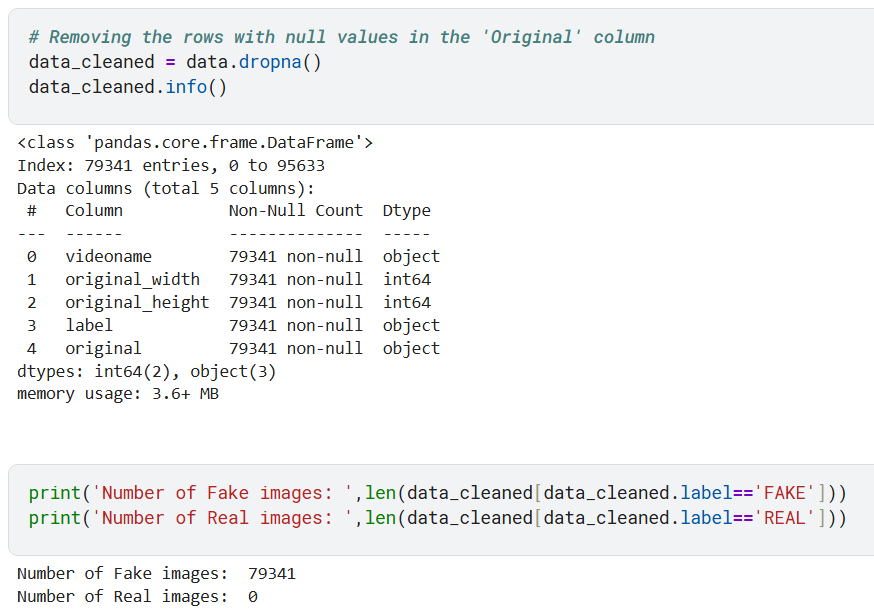


In [7]:
print('Number of Fake images: ',len(data[data.label=='FAKE']))
print('Number of Real images: ',len(data[data.label=='REAL']))

Number of Fake images:  79341
Number of Real images:  16293


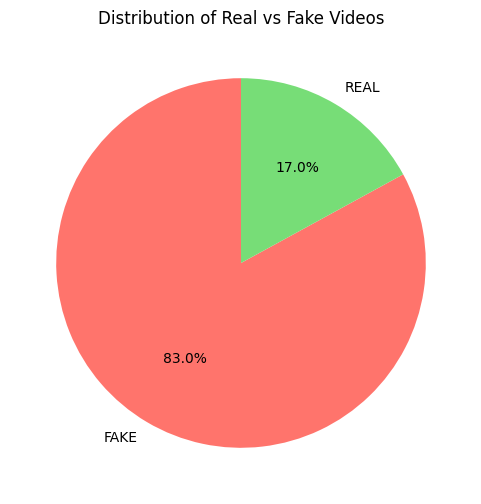

In [8]:
import matplotlib.pyplot as plt
label_counts = data['label'].value_counts()
label_counts.plot.pie(autopct='%1.1f%%', startangle=90, colors=['#ff746c', '#77DD77'], figsize=(6, 6))
plt.title('Distribution of Real vs Fake Videos')
plt.ylabel('') 
plt.show()

## **Selecting a subset of the dataset:**
The dataset has 95K images out of which we would be working on 9K real and 9K fake images.

In [5]:
real_df = data[data["label"] == "REAL"]
fake_df = data[data["label"] == "FAKE"]
sample_size = 9000

real_df = real_df.sample(sample_size, random_state=42)
fake_df = fake_df.sample(sample_size, random_state=42)

sample_data = pd.concat([real_df, fake_df])

In [10]:
sample_data.head()

,videoname,original_width,original_height,label,original
83199,awtrjchfyi.mp4,223,223,REAL,NaN
53211,yziqsfcxcv.mp4,129,129,REAL,NaN
47562,aahncigwte.mp4,268,268,REAL,NaN
84692,turhmezheg.mp4,108,108,REAL,NaN
22847,zjtifyduih.mp4,223,223,REAL,NaN


In [8]:
from sklearn.model_selection import train_test_split
Train_set, Test_set = train_test_split(sample_data,test_size=0.2,random_state=42,stratify=sample_data['label'])
Train_set, Val_set  = train_test_split(Train_set,test_size=0.3,random_state=42,stratify=Train_set['label'])

In [12]:
Train_set.shape,Val_set.shape,Test_set.shape

((10080, 5), (4320, 5), (3600, 5))

**Significance of each part**:  
- Train set: Used to train the model
- Validation set: Used to tune the hyperparameters, doesn't train the model. Indicates if the model overfits.
- Test set: Used to test the model.

In [13]:
from tabulate import tabulate

datasets = [("Train Set", Train_set), ("Validation Set", Val_set), ("Test Set", Test_set)]
table = []
for name, dataset in datasets:
    fake_count = (dataset['label'] == 'FAKE').sum()
    real_count = (dataset['label'] == 'REAL').sum()
    table.append([name, fake_count, real_count])

print(tabulate(table, headers=["Dataset", "Fake Images", "Real Images"], tablefmt="grid"))

+----------------+---------------+---------------+
| Dataset        |   Fake Images |   Real Images |
+================+===============+===============+
| Train Set      |          5040 |          5040 |
+----------------+---------------+---------------+
| Validation Set |          2160 |          2160 |
+----------------+---------------+---------------+
| Test Set       |          1800 |          1800 |
+----------------+---------------+---------------+


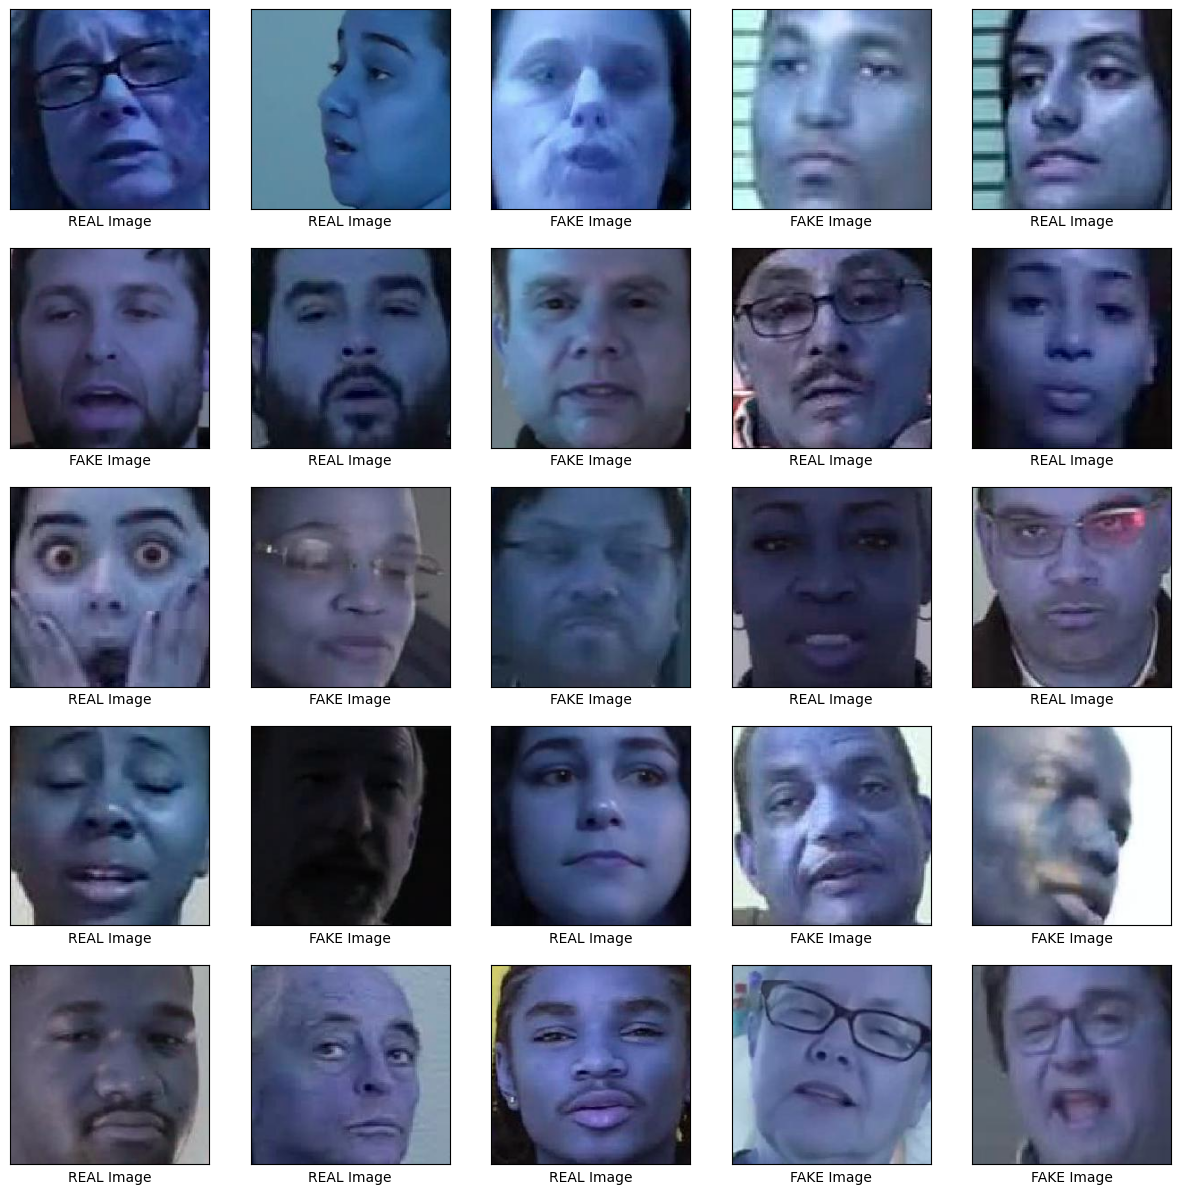

In [14]:
import matplotlib.pyplot as plt
import  cv2

plt.figure(figsize=(15,15))

for cur,i in enumerate(Train_set.index[25:50]):
    plt.subplot(5,5,cur+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    
    plt.imshow(cv2.imread('../input/deepfake-faces/faces_224/'+Train_set.loc[i,'videoname'][:-4]+'.jpg'))
    
    if(Train_set.loc[i,'label']=='FAKE'):
        plt.xlabel('FAKE Image')
    else:
        plt.xlabel('REAL Image')
        
plt.show()

## **Creating a dataset with images and labels**

In [6]:
def load_images_and_labels(df, folder_path):
    images = []
    labels = []
    for video in tqdm(df['videoname']):
        img_path = os.path.join(folder_path, video.replace(".mp4", ".jpg"))
        if os.path.exists(img_path):
            img = Image.open(img_path).resize((128, 128))
            images.append(np.array(img))
            labels.append(1 if df[df['videoname'] == video]['label'].values[0] == 'FAKE' else 0)
    return np.array(images), np.array(labels)

In [7]:
image_dir = os.path.join(deepfake_faces_path, 'faces_224')

def get_dataset(df, image_dir, batch_size=32, shuffle=True):
    filepaths = []
    labels = []
    for i, row in df.iterrows():
        img_name = row['videoname'].replace('.mp4', '.jpg')
        path = os.path.join(image_dir, img_name)
        if os.path.exists(path):
            filepaths.append(path)
            labels.append(1 if row['label'] == 'FAKE' else 0)

    ds = tf.data.Dataset.from_tensor_slices((filepaths, labels))

    def _parse_function(filename, label):
        image = tf.io.read_file(filename)
        image = tf.image.decode_jpeg(image, channels=3)
        image = tf.image.resize(image, [128, 128])
        image = image / 255.0
        return image, label

    ds = ds.map(_parse_function, num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(buffer_size=1000)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

In [9]:
train_ds = get_dataset(Train_set, image_dir, batch_size=64)
val_ds = get_dataset(Val_set, image_dir, batch_size=64, shuffle=False)
test_ds = get_dataset(Test_set, image_dir, batch_size=64, shuffle=False)

I0000 00:00:1746094726.274863      31 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


# **Custom CNN Model**

In [10]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense, Input

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Dropout(0.25),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Dropout(0.25),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Dropout(0.25),

    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

In [28]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)                   │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_19 (Conv2D)                   │ (None, 124, 124, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 62, 62, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 62, 62, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_20 (Conv2D)                   │ (None, 60, 60, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_21 (Conv2D)                   │ (None, 28, 28, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │       1,605,696 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,735,937 (6.62 MB)

 Trainable params: 1,735,937 (6.62 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
# Callbacks
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, verbose=1)

In [20]:
# Defining the model checkpoint callback
from tensorflow.keras.callbacks import ModelCheckpoint
checkpoint_callback = ModelCheckpoint(
    'deepfake_custom_model.keras',   
    monitor='val_loss', 
    verbose=1,          
    save_best_only=True, 
    mode='min',         
    save_weights_only=False, 
)

In [11]:
from keras.optimizers import Adam
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

In [22]:
# Train
history = model.fit(train_ds, validation_data=val_ds, epochs=40, callbacks=[early_stop, lr_scheduler, checkpoint_callback])

Epoch 1/40


I0000 00:00:1746090435.674348      92 service.cc:148] XLA service 0x7fa6f0002e20 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1746090435.675296      92 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1746090436.084489      92 cuda_dnn.cc:529] Loaded cuDNN version 90300


  3/158 ━━━━━━━━━━━━━━━━━━━━ 9s 62ms/step - accuracy: 0.6267 - loss: 0.8483  

I0000 00:00:1746090443.409216      92 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - accuracy: 0.5003 - loss: 0.7157
Epoch 1: val_loss improved from inf to 0.69288, saving model to deepfake_custom_model.keras
158/158 ━━━━━━━━━━━━━━━━━━━━ 38s 162ms/step - accuracy: 0.5002 - loss: 0.7156 - val_accuracy: 0.5030 - val_loss: 0.6929 - learning_rate: 0.0010
Epoch 2/40
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.5010 - loss: 0.6932
Epoch 2: val_loss did not improve from 0.69288
158/158 ━━━━━━━━━━━━━━━━━━━━ 8s 51ms/step - accuracy: 0.5010 - loss: 0.6932 - val_accuracy: 0.5192 - val_loss: 0.6929 - learning_rate: 0.0010
Epoch 3/40
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.5082 - loss: 0.6929
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.

Epoch 3: val_loss did not improve from 0.69288
158/158 ━━━━━━━━━━━━━━━━━━━━ 9s 53ms/step - accuracy: 0.5083 - loss: 0.6929 - val_accuracy: 0.5000 - val_loss: 0.6933 - learning_rate: 0.0010
Epoch 4/40
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - ac

In [23]:
model.save("deepfake_custom_model.h5")

In [24]:
score = model.evaluate(test_ds)
print("Test Accuracy: {:.2f}%".format(score[1]*100))

57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 84ms/step - accuracy: 0.6824 - loss: 0.5831
Test Accuracy: 68.50%


In [25]:
# Plotting the training and validation accuracies
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

print(f"Final Training Accuracy: {train_accuracy[-1]:.2f}")
print(f"Final Validation Accuracy: {val_accuracy[-1]:.2f}")

Final Training Accuracy: 0.73
Final Validation Accuracy: 0.68


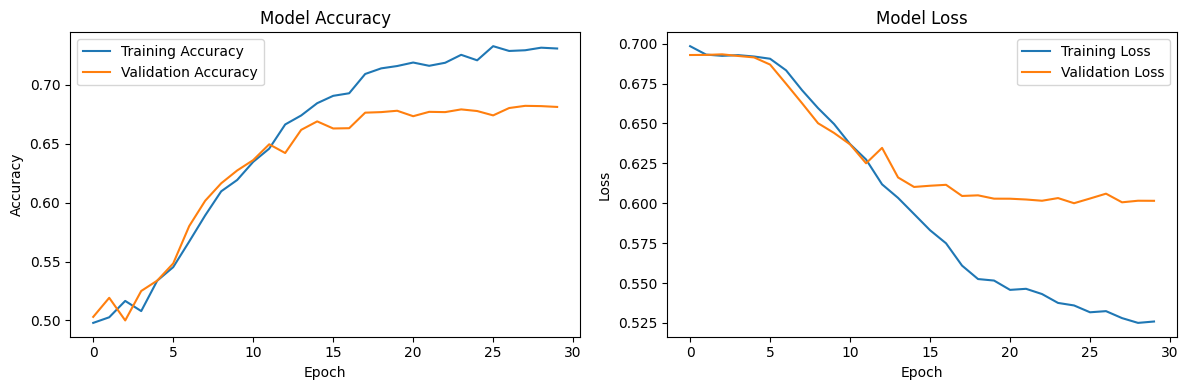

In [26]:
# Plot accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_accuracy, label='Training Accuracy')
plt.plot(val_accuracy, label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

## **U-Net Implementation from scratch**

In [27]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Dropout, Conv2DTranspose, concatenate, GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model

In [28]:
IMG_HEIGHT, IMG_WIDTH = 128, 128
num_classes = 1 

In [29]:
def build_unet(input_size=(IMG_HEIGHT, IMG_WIDTH, 3)):
    inputs = Input(input_size)

    # Encoder
    c1 = Conv2D(16, (3, 3), activation='relu', padding='same')(inputs)
    c1 = Conv2D(16, (3, 3), activation='relu', padding='same')(c1)
    p1 = MaxPooling2D((2, 2))(c1)

    c2 = Conv2D(32, (3, 3), activation='relu', padding='same')(p1)
    c2 = Conv2D(32, (3, 3), activation='relu', padding='same')(c2)
    p2 = MaxPooling2D((2, 2))(c2)

    c3 = Conv2D(64, (3, 3), activation='relu', padding='same')(p2)
    c3 = Conv2D(64, (3, 3), activation='relu', padding='same')(c3)
    p3 = MaxPooling2D((2, 2))(c3)

    # Bottleneck
    c4 = Conv2D(128, (3, 3), activation='relu', padding='same')(p3)
    c4 = Conv2D(128, (3, 3), activation='relu', padding='same')(c4)

    # Decoder
    u5 = Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(c4)
    u5 = concatenate([u5, c3])
    c5 = Conv2D(64, (3, 3), activation='relu', padding='same')(u5)
    c5 = Conv2D(64, (3, 3), activation='relu', padding='same')(c5)

    u6 = Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same')(c5)
    u6 = concatenate([u6, c2])
    c6 = Conv2D(32, (3, 3), activation='relu', padding='same')(u6)
    c6 = Conv2D(32, (3, 3), activation='relu', padding='same')(c6)

    u7 = Conv2DTranspose(16, (2, 2), strides=(2, 2), padding='same')(c6)
    u7 = concatenate([u7, c1])
    c7 = Conv2D(16, (3, 3), activation='relu', padding='same')(u7)
    c7 = Conv2D(16, (3, 3), activation='relu', padding='same')(c7)

    # Classification head
    gap = GlobalAveragePooling2D()(c7)
    d1 = Dense(128, activation='relu')(gap)
    d1 = Dropout(0.5)(d1)
    outputs = Dense(num_classes, activation='sigmoid')(d1)

    model = Model(inputs, outputs)
    return model

In [30]:
model_unet = build_unet()
model_unet.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
model_unet.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1             │ (None, 128, 128, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_4 (Conv2D)         │ (None, 128, 128, 16)   │            448 │ input_layer_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_5 (Conv2D)         │ (None, 128, 128, 16)   │          2,320 │ conv2d_4[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_3           │ (None, 64, 64, 16)     │              0 │ conv2d_5[0][0]         │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_6 (Conv2D)         │ (None, 64, 64, 32)     │          4,640 │ max_pooling2d_3[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_7 (Conv2D)         │ (None, 64, 64, 32)     │          9,248 │ conv2d_6[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_4           │ (None, 32, 32, 32)     │              0 │ conv2d_7[0][0]         │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_8 (Conv2D)         │ (None, 32, 32, 64)     │         18,496 │ max_pooling2d_4[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_9 (Conv2D)         │ (None, 32, 32, 64)     │         36,928 │ conv2d_8[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_5           │ (None, 16, 16, 64)     │              0 │ conv2d_9[0][0]         │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_10 (Conv2D)        │ (None, 16, 16, 128)    │         73,856 │ max_pooling2d_5[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_11 (Conv2D)        │ (None, 16, 16, 128)    │        147,584 │ conv2d_10[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_transpose          │ (None, 32, 32, 64)     │         32,832 │ conv2d_11[0][0]        │
│ (Conv2DTranspose)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate (Concatenate) │ (None, 32, 32, 128)    │              0 │ conv2d_transpose[0][0… │
│                           │                        │                │ conv2d_9[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_12 (Conv2D)        │ (None, 32, 32, 64)     │         73,792 │ concatenate[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_13 (Conv2D)        │ (None, 32, 32, 64)     │         36,928 │ conv2d_12[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_transpose_1   

 Total params: 484,321 (1.85 MB)

 Trainable params: 484,321 (1.85 MB)

 Non-trainable params: 0 (0.00 B)

In [31]:
early_stop_unet = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
lr_scheduler_unet = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, verbose=1)

In [32]:
checkpoint_callback_unet = ModelCheckpoint(
    'deepfake_unet_model.keras',  
    monitor='val_loss', 
    verbose=1,          
    save_best_only=True, 
    mode='min',         
    save_weights_only=False, 
)

In [33]:
history_unet = model_unet.fit(train_ds, validation_data=val_ds, epochs=40,callbacks=[early_stop_unet, lr_scheduler_unet, checkpoint_callback_unet])

Epoch 1/40
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.4942 - loss: 0.6935
Epoch 1: val_loss improved from inf to 0.69314, saving model to deepfake_unet_model.keras
158/158 ━━━━━━━━━━━━━━━━━━━━ 37s 132ms/step - accuracy: 0.4942 - loss: 0.6935 - val_accuracy: 0.5000 - val_loss: 0.6931 - learning_rate: 0.0010
Epoch 2/40
157/158 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.5048 - loss: 0.6933
Epoch 2: val_loss improved from 0.69314 to 0.69312, saving model to deepfake_unet_model.keras
158/158 ━━━━━━━━━━━━━━━━━━━━ 16s 95ms/step - accuracy: 0.5047 - loss: 0.6933 - val_accuracy: 0.5030 - val_loss: 0.6931 - learning_rate: 0.0010
Epoch 3/40
157/158 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.4963 - loss: 0.6932
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.

Epoch 3: val_loss did not improve from 0.69312
158/158 ━━━━━━━━━━━━━━━━━━━━ 16s 97ms/step - accuracy: 0.4964 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6932 - learning_rate: 0.0010


In [34]:
score_unet = model_unet.evaluate(test_ds)
print("Test Accuracy: {:.2f}%".format(score_unet[1]*100))

57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - accuracy: 0.6345 - loss: 0.6353
Test Accuracy: 63.89%


In [35]:
model_unet.save("deepfake_unet_model.h5")

In [36]:
# Plotting the training and validation accuracies
train_accuracy = history_unet.history['accuracy']
val_accuracy = history_unet.history['val_accuracy']

print(f"Final Training Accuracy: {train_accuracy[-1]:.2f}")
print(f"Final Validation Accuracy: {val_accuracy[-1]:.2f}")

Final Training Accuracy: 0.65
Final Validation Accuracy: 0.64


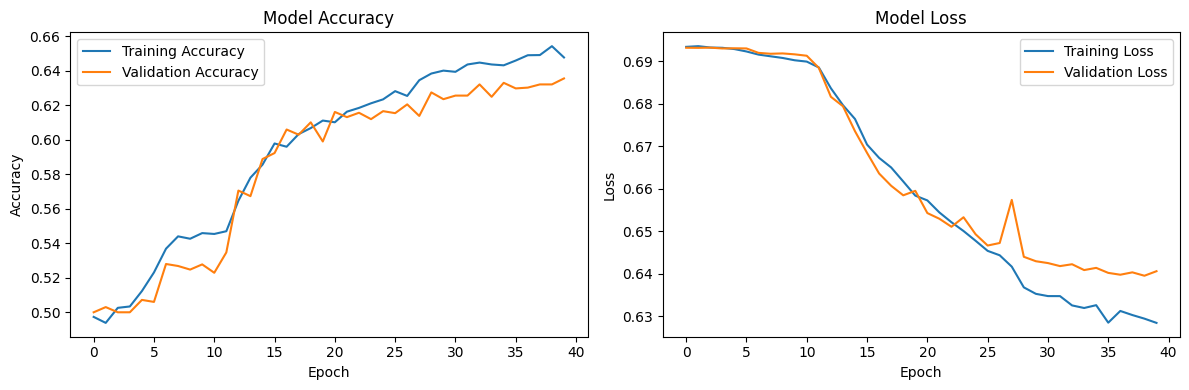

In [37]:
# Plot accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_accuracy, label='Training Accuracy')
plt.plot(val_accuracy, label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history_unet.history['loss'], label='Training Loss')
plt.plot(history_unet.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

## **Improved U-net**

In [12]:
from tensorflow.keras.layers import (Input, Conv2D, BatchNormalization, Activation,MaxPooling2D, Dropout, Conv2DTranspose, concatenate, 
                                     GlobalAveragePooling2D,  Dense )
from tensorflow.keras.models import Model
from tensorflow.keras import regularizers

In [13]:
IMG_HEIGHT, IMG_WIDTH = 128, 128
NUM_CLASSES = 1        
WEIGHT_DECAY = 1e-4    # L2 regularization strength

In [14]:
def conv_block(x, filters):
    """Two 3×3 Convs + BatchNorm + ReLU, with L2 weight decay."""
    x = Conv2D(filters, 3, padding='same',
               kernel_initializer='he_normal',
               kernel_regularizer=regularizers.l2(WEIGHT_DECAY))(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Conv2D(filters, 3, padding='same',
               kernel_initializer='he_normal',
               kernel_regularizer=regularizers.l2(WEIGHT_DECAY))(x)
    x = BatchNormalization()(x)
    return Activation('relu')(x)

In [15]:
def build_unet_improved(input_size=(IMG_HEIGHT, IMG_WIDTH, 3)):
    inputs = Input(input_size)

    # Encoder
    c1 = conv_block(inputs, 32)
    p1 = MaxPooling2D((2, 2))(c1)

    c2 = conv_block(p1, 64)
    p2 = MaxPooling2D((2, 2))(c2)

    c3 = conv_block(p2, 128)
    p3 = MaxPooling2D((2, 2))(c3)

    c4 = conv_block(p3, 256)
    p4 = MaxPooling2D((2, 2))(c4)

    # Bottleneck
    b  = conv_block(p4, 512)
    b  = Dropout(0.5)(b)

    # Decoder
    u5 = Conv2DTranspose(256, (2, 2), strides=(2, 2), padding='same')(b)
    u5 = concatenate([u5, c4])
    c5 = conv_block(u5, 256)

    u6 = Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(c5)
    u6 = concatenate([u6, c3])
    c6 = conv_block(u6, 128)

    u7 = Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(c6)
    u7 = concatenate([u7, c2])
    c7 = conv_block(u7, 64)

    u8 = Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same')(c7)
    u8 = concatenate([u8, c1])
    c8 = conv_block(u8, 32)

    # Classification head
    gap = GlobalAveragePooling2D()(c8)
    d1  = Dense(256, activation='relu',
                kernel_regularizer=regularizers.l2(WEIGHT_DECAY))(gap)
    d1  = Dropout(0.5)(d1)
    outputs = Dense(NUM_CLASSES, activation='sigmoid')(d1)

    return Model(inputs, outputs, name="UNet_Classifier")

In [16]:
model_unet_improved = build_unet_improved()
model_unet_improved.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
model_unet_improved.summary()

Model: "UNet_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1             │ (None, 128, 128, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_4 (Conv2D)         │ (None, 128, 128, 32)   │            896 │ input_layer_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization       │ (None, 128, 128, 32)   │            128 │ conv2d_4[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation (Activation)   │ (None, 128, 128, 32)   │              0 │ batch_normalization[0… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_5 (Conv2D)         │ (None, 128, 128, 32)   │          9,248 │ activation[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_1     │ (None, 128, 128, 32)   │            128 │ conv2d_5[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_1 (Activation) │ (None, 128, 128, 32)   │              0 │ batch_normalization_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_3           │ (None, 64, 64, 32)     │              0 │ activation_1[0][0]     │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_6 (Conv2D)         │ (None, 64, 64, 64)     │         18,496 │ max_pooling2d_3[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_2     │ (None, 64, 64, 64)     │            256 │ conv2d_6[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_2 (Activation) │ (None, 64, 64, 64)     │              0 │ batch_normalization_2… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_7 (Conv2D)         │ (None, 64, 64, 64)     │         36,928 │ activation_2[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_3     │ (None, 64, 64, 64)     │            256 │ conv2d_7[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_3 (Activation) │ (None, 64, 64, 64)     │              0 │ batch_normalization_3… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_4           │ (None, 32, 32, 64)     │              0 │ activation_3[0][0]     │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_8 (Conv2D)         │ (None, 32, 32, 128)    │         73,856 │ max_pooling2d_4[0][0]  │
├──────────────────────

 Total params: 7,780,545 (29.68 MB)

 Trainable params: 7,774,657 (29.66 MB)

 Non-trainable params: 5,888 (23.00 KB)

In [21]:
early_stop_unet_improved = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
lr_scheduler_unet_improved = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, verbose=1)

In [22]:
checkpoint_callback_unet_improved = ModelCheckpoint(
    'deepfake_unet_improved_model.keras',  
    monitor='val_loss', 
    verbose=1,          
    save_best_only=True, 
    mode='min',         
    save_weights_only=False, 
)

In [25]:
history_unet_improved = model_unet_improved.fit(train_ds, validation_data=val_ds, epochs=40,
                                                callbacks=[early_stop_unet_improved, lr_scheduler_unet_improved, checkpoint_callback_unet_improved])

Epoch 1/40
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - accuracy: 0.6709 - auc: 0.7289 - loss: 0.6559
Epoch 1: val_loss improved from 0.70313 to 0.65885, saving model to deepfake_unet_improved_model.keras
158/158 ━━━━━━━━━━━━━━━━━━━━ 26s 163ms/step - accuracy: 0.6709 - auc: 0.7290 - loss: 0.6558 - val_accuracy: 0.6535 - val_auc: 0.7252 - val_loss: 0.6589 - learning_rate: 4.0000e-05
Epoch 2/40
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - accuracy: 0.6920 - auc: 0.7490 - loss: 0.6319
Epoch 2: val_loss did not improve from 0.65885
158/158 ━━━━━━━━━━━━━━━━━━━━ 26s 159ms/step - accuracy: 0.6920 - auc: 0.7490 - loss: 0.6319 - val_accuracy: 0.6407 - val_auc: 0.7281 - val_loss: 0.6631 - learning_rate: 4.0000e-05
Epoch 3/40
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - accuracy: 0.6929 - auc: 0.7555 - loss: 0.6247
Epoch 3: val_loss improved from 0.65885 to 0.64563, saving model to deepfake_unet_improved_model.keras
158/158 ━━━━━━━━━━━━━━━━━━━━ 26s 163ms/step - accuracy: 0.6929 - auc: 0.7555 - lo

In [26]:
score_unet_improved = model_unet_improved.evaluate(test_ds)
print("Test Accuracy: {:.2f}%".format(score_unet_improved[1]*100))

57/57 ━━━━━━━━━━━━━━━━━━━━ 11s 195ms/step - accuracy: 0.7159 - auc: 0.7800 - loss: 0.6011
Test Accuracy: 72.22%


In [27]:
model_unet_improved.save("deepfake_unet_improved_model.h5")

In [28]:
train_accuracy = history_unet_improved.history['accuracy']
val_accuracy = history_unet_improved.history['val_accuracy']

print(f"Final Training Accuracy: {train_accuracy[-1]:.2f}")
print(f"Final Validation Accuracy: {val_accuracy[-1]:.2f}")

Final Training Accuracy: 0.76
Final Validation Accuracy: 0.70


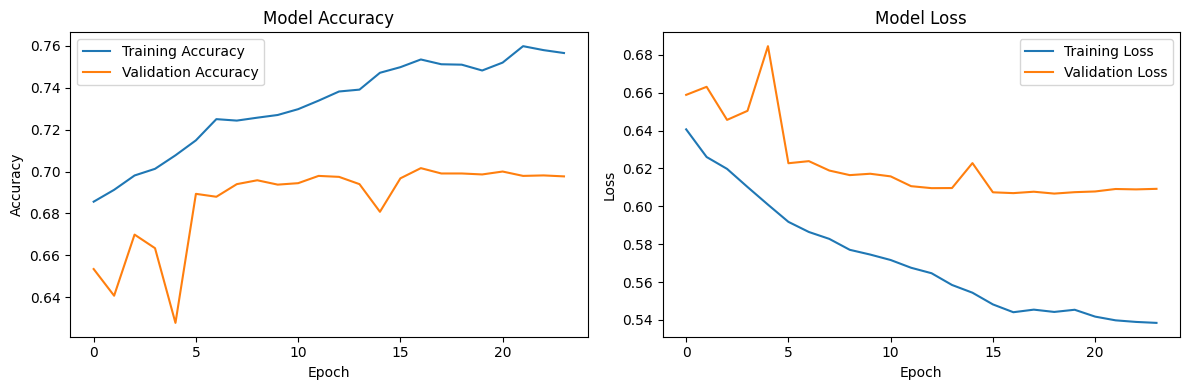

In [30]:
# Plot accuracy
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_accuracy, label='Training Accuracy')
plt.plot(val_accuracy, label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history_unet_improved.history['loss'], label='Training Loss')
plt.plot(history_unet_improved.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()